In [20]:
import warnings

warnings.filterwarnings("ignore")

# QuantNado — Multi-Modal Dataset Exploration

This notebook walks through a complete analysis workflow using **QuantNado**: a toolkit for
efficient Zarr-backed storage and analysis of multi-modal genomic signal.

**Workflow covered:**
1. Create a unified multi-modal dataset (coverage + methylation + variants)
2. Load and inspect the dataset
3. Reduce signal over genomic regions (BED file)
4. Sample-sample correlation heatmap
5. PCA for quality control and exploratory analysis
6. Generate a feature count matrix for DESeq2
7. Extract raw per-position signal over specific regions
8. Methylation data (CpG-level from MethylDackel bedGraph)
9. Variant calls (SNP/indel from VCF)

---

## Setup

> **Dependencies**  
> Install the optional example dependencies before running this notebook:
> ```bash
> pip install "quantnado[example]"
> ```
> This adds `ipykernel` and `matplotlib` on top of the core install.

In [21]:
import subprocess
import tarfile
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyranges1 as pr
import seaborn as sns

from quantnado import QuantNado
from quantnado.dataset import MultiomicsStore
from quantnado.dataset.pca import plot_pca_scatter, plot_pca_scree


## Data

The test dataset (BAM files, chr21 only) needs to be downloaded before running this notebook.
Run the cell below to fetch and extract it automatically, or manually:

```bash
# From the example/ directory
curl -L https://userweb.molbiol.ox.ac.uk/public/project/milne_group/cchahrou/quantnado/seqnado_output.tar.gz \
  | tar -xz -C multiomics_run/

```

The reference files (`reference/chr21.gtf`, `reference/promoters_1024bp.bed`) are already included in the repository.

---

In [22]:
DATA_URL = "https://userweb.molbiol.ox.ac.uk/public/project/milne_group/cchahrou/quantnado/seqnado_output.tar.gz"
REF_URL = "https://userweb.molbiol.ox.ac.uk/public/project/milne_group/cchahrou/quantnado/reference.tar.gz"
RUN_DIR = Path("multiomics_run")
RUN_DIR.mkdir(parents=True, exist_ok=True)

if not (RUN_DIR / "seqnado_output").exists():
    print("Downloading test data...")
    archive = RUN_DIR / "seqnado_output.tar.gz"
    urllib.request.urlretrieve(DATA_URL, archive)
    print("Extracting...")
    with tarfile.open(archive) as tf:
        tf.extractall(RUN_DIR)
    archive.unlink()
    print("Done.")
else:
    print("Test data already present — skipping download.")

if not (RUN_DIR / "reference").exists():
    print("Downloading reference data...")
    urllib.request.urlretrieve(REF_URL, RUN_DIR / "reference.tar.gz")
    with tarfile.open(RUN_DIR / "reference.tar.gz") as tf:
        tf.extractall(RUN_DIR)
    (RUN_DIR / "reference.tar.gz").unlink()
    print("Done.")
else:
    print("Reference data already present — skipping download.")

Test data already present — skipping download.
Reference data already present — skipping download.


In [23]:
# Paths relative to this notebook (example/)
OUT_DIR = RUN_DIR / "seqnado_output"
REF_DIR = RUN_DIR / "reference"

MS_PATH = RUN_DIR / "dataset.zarr"  # MultiomicsStore directory
BED_FILE = str(REF_DIR / "promoters_1024bp.bed")
GTF_FILE = str(REF_DIR / "chr21.gtf")
FIG_DIR = RUN_DIR / "figures"

FIG_DIR.mkdir(parents=True, exist_ok=True)

---
## Create a Unified Multi-Modal Dataset

`MultiomicsStore.from_files()` creates one directory (`dataset/`) containing a
sub-Zarr for each supplied modality:

| Sub-store | Input | What is stored |
|---|---|---|
| `coverage.zarr` | BAM files | per-base read depth (dense, sample × position) |
| `methylation.zarr` | MethylDackel bedGraph | CpG methylation % and counts (sparse) |
| `variants.zarr` | VCF.gz files | genotype, allele depths, quality (sparse) |

Run this cell once; it is skipped automatically if the store already exists.

In [24]:
# shutil.rmtree(MS_PATH, ignore_errors=True)

if not MS_PATH.exists():
    bam_files = sorted(OUT_DIR.rglob("*.bam"))
    bedgraph_files = sorted((OUT_DIR / "meth/methylation/methyldackel").glob("*.bedGraph"))
    vcf_files = sorted((OUT_DIR / "snp/variant").glob("*.vcf.gz"))

    print(f"BAM files       : {len(bam_files)}")
    print(f"bedGraph files  : {[f.name for f in bedgraph_files]}")
    print(f"VCF files       : {[f.name for f in vcf_files]}")

    cmd = [
        "quantnado",
        "create-dataset",
        "--output",
        str(MS_PATH),
        "--bam",
        ",".join(str(f) for f in bam_files),
        "--bedgraph",
        ",".join(str(f) for f in bedgraph_files),
        "--bedgraph-sample-names",
        ",".join(f.name.split("_hg38")[0] for f in bedgraph_files),
        "--vcf",
        ",".join(str(f) for f in vcf_files),
        "--max-workers",
        "4",
        "--log-file",
        "dataset_creation.log",
        "--verbose",
        "--overwrite",
        "--resume",
    ]

    print("Running QuantNado:")
    subprocess.run(cmd, check=True)
    print("\nDone.")
else:
    print(f"Dataset already exists at {MS_PATH} — skipping creation.")

Dataset already exists at multiomics_run/dataset.zarr — skipping creation.


---
## Load and Inspect the Dataset

In [25]:
# Open the unified store
ms = MultiomicsStore.open(MS_PATH)
print(ms)

# QuantNado wraps the coverage sub-store and provides reduce / PCA / feature-count methods
qn = QuantNado(ms.coverage)

2026-03-07 17:18:57.330 | INFO     | quantnado.dataset.bam:_load_existing:374 - Resuming existing store at multiomics_run/dataset.zarr/coverage.zarr
2026-03-07 17:18:57.332 | INFO     | quantnado.dataset.methylation:_load_existing:178 - Resuming existing MethylStore at multiomics_run/dataset.zarr/methylation.zarr
2026-03-07 17:18:57.334 | INFO     | quantnado.dataset.variants:_load_existing:228 - Resuming existing VariantStore at multiomics_run/dataset.zarr/variants.zarr


MultiomicsStore at 'multiomics_run/dataset.zarr'
  modalities : ['coverage', 'methylation', 'variants']
  coverage    : 9 samples, 1 chrom(s)
  methylation : 2 samples, 1 chrom(s)
  variants    : 1 samples, 1 chrom(s)


In [26]:
print("Available modalities:", ms.modalities)
print("Chromosomes        :", ms.chromosomes)
print()
for modality, names in ms.samples.items():
    print(f"{modality:<12}: {names}")

Available modalities: ['coverage', 'methylation', 'variants']
Chromosomes        : ['chr21']

coverage    : ['atac', 'chip-rx_MLL', 'meth-rep1', 'meth-rep2', 'rna-spikein-control-rep1', 'rna-spikein-control-rep2', 'rna-spikein-treated-rep1', 'rna-spikein-treated-rep2', 'snp']
methylation : ['meth-rep1', 'meth-rep2']
variants    : ['snp']


In [27]:
# Unified metadata — one row per sample, with a 'modalities' column
metadata = ms.get_metadata()
metadata

,sample_hash,completed,sparsity,modalities
sample_id,,,,
atac,96ae824c5c35c004df1b9db3db07283e,True,99.904594,coverage
chip-rx_MLL,ea6b78070b8d28b7a0239eca45893bd4,True,95.253860,coverage
meth-rep1,f5ba0583afa25559ed30c9e8e2709f07,True,94.216675,"coverage, methylation"
meth-rep2,bcc7e3bf38ae81f6947662683190e221,True,93.745697,"coverage, methylation"
rna-spikein-control-rep1,2414b9280438e98f0c7cf50d5324bc2f,True,97.987144,coverage
rna-spikein-control-rep2,9b73f71b7438cdc6081be20663ee4929,True,98.167877,coverage
rna-spikein-treated-rep1,53da554c5e301439abe48b13b8838b67,True,96.408737,coverage
rna-spikein-treated-rep2,c2ac62c58d5c053b6f9400e46e08441f,True,96.751144,coverage
snp,e9eae880d15aaf4929da8db87d4dcb83,True,99.945015,"coverage, variants"


---
## Reduce Signal over Genomic Regions

Aggregate per-base signal across genomic intervals (e.g. promoters, peaks) to produce a
compact `(regions × samples)` matrix. Useful for downstream analysis such as PCA and clustering.

Reduction methods: `mean`, `sum`, `max`, `min`, `median`.

In [28]:
# Reduce mean signal over each promoter window
promoter_signal = qn.reduce(intervals_path=BED_FILE, reduction="mean")
promoter_signal

2026-03-07 17:18:57.410 | INFO     | quantnado.dataset.reduce:_log_chromosome_overlap:60 - Chromosome compatibility check: 1 shared chromosomes out of 1 in BED/GTF file and 1 in dataset
2026-03-07 17:18:57.410 | DEBUG    | quantnado.dataset.reduce:_log_chromosome_overlap:66 - Shared chromosomes: ['chr21']


<xarray.Dataset> Size: 356kB
Dimensions:       (ranges: 1456, sample: 9)
Coordinates:
  * ranges        (ranges) int64 12kB 0 1 2 3 4 5 ... 1451 1452 1453 1454 1455
    range_index   (ranges) int64 12kB 0 1 2 3 4 5 ... 1451 1452 1453 1454 1455
    start         (ranges) int64 12kB 5011852 5011852 ... 46635162 46635162
    end           (ranges) int64 12kB 5012876 5012876 ... 46636186 46636186
    range_length  (ranges) int64 12kB 1024 1024 1024 1024 ... 1024 1024 1024
    contig        (ranges) object 12kB 'chr21' 'chr21' ... 'chr21' 'chr21'
    strand        (ranges) object 12kB '+' '+' '+' '+' '+' ... '+' '+' '+' '+'
    name          (ranges) object 12kB 'LOC124905051:XM_047441065.1' ... 'PRM...
  * sample        (sample) <U24 864B 'atac' 'chip-rx_MLL' ... 'snp'
Data variables:
    sum           (ranges, sample) float32 52kB dask.array<chunksize=(1456, 1), meta=np.ndarray>
    count         (ranges, sample) int64 105kB dask.array<chunksize=(1456, 1), meta=np.ndarray>
    mean          (ranges, sample) float64 105kB dask.array<chunksize=(1456, 1), meta=np.ndarray>

### Clustered Heatmap of Promoter Signal

In [ ]:
# Signal matrix: (regions × samples)
signal_matrix = promoter_signal["mean"].values
print(f"Signal matrix shape: {signal_matrix.shape}  (regions × samples)")

# Log-transform to compress dynamic range, then cluster.
# Drop zero-variance samples (e.g. WGS/SNP BAMs with no promoter enrichment)
# to avoid NaN distances in clustering and correlation.
log_signal = np.log1p(signal_matrix)
sample_var = log_signal.var(axis=0)
keep = sample_var > 0
log_signal = log_signal[:, keep]
samples_informative = [s for s, k in zip(qn.samples, keep) if k]
if (~keep).any():
    dropped = [s for s, k in zip(qn.samples, keep) if not k]
    print(f"Dropped zero-variance samples: {dropped}")

g = sns.clustermap(
    log_signal,
    cmap="mako",
    yticklabels=False,
    xticklabels=samples_informative,
    figsize=(5, 6),
    col_cluster=True,
    row_cluster=True,
    cbar_kws={"label": "log1p(mean signal)"},
    cbar_pos=(1, 0.5, 0.01, 0.2),  # (left, bottom, width, height)
    dendrogram_ratio=0.1,
)
g.figure.suptitle("Promoter signal — clustered heatmap", y=1.02)
g.savefig(FIG_DIR / "promoter_clustermap.png", bbox_inches="tight")
plt.show()

### Sample–Sample Correlation

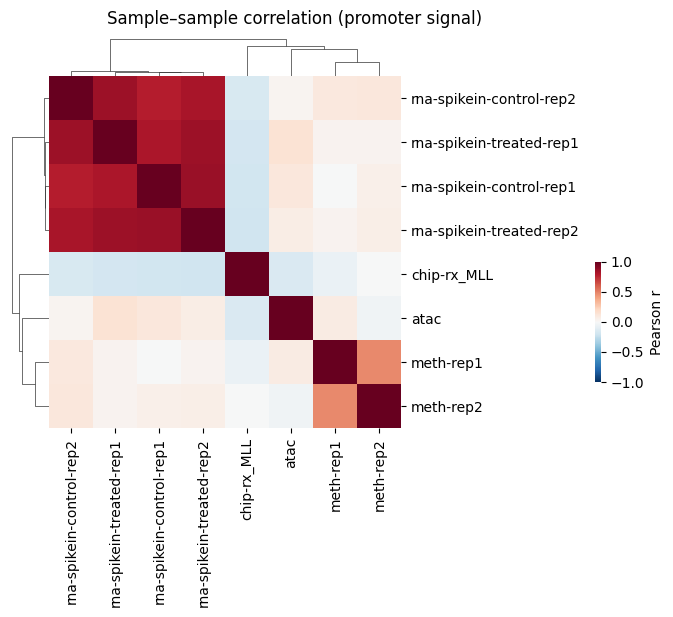

In [ ]:
corr = np.corrcoef(log_signal.T)  # samples × samples

g = sns.clustermap(
    corr,
    xticklabels=samples_informative,
    yticklabels=samples_informative,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    square=True,
    figsize=(6, 6),
    cbar_kws={"label": "Pearson r"},
    cbar_pos=(1, 0.4, 0.01, 0.2),
    dendrogram_ratio=0.1,
)
g.figure.suptitle("Sample–sample correlation (promoter signal)", y=1.02)
g.figure.tight_layout()
g.savefig(FIG_DIR / "sample_correlation.png")
plt.show()

---
## Feature Count Matrix (DESeq2-compatible)

Sum signal across gene bodies to produce an integer count matrix ready for differential
expression analysis in DESeq2 or edgeR.

In [ ]:
counts, features = qn.count_features(
    gtf_file=GTF_FILE,
    feature_type="transcript",
    feature_id_col=["gene_id", "transcript_id"],
    integerize=True,
)

print(f"Count matrix: {counts.shape[0]} genes × {counts.shape[1]} samples")
print(f"Feature metadata: {features.shape[0]} features × {features.shape[1]} columns")
counts.head(10)

2026-03-07 17:17:27.134 | INFO     | quantnado.dataset.reduce:_log_chromosome_overlap:60 - Chromosome compatibility check: 1 shared chromosomes out of 1 in input ranges and 1 in dataset
2026-03-07 17:17:27.134 | DEBUG    | quantnado.dataset.reduce:_log_chromosome_overlap:66 - Shared chromosomes: ['chr21']


Count matrix: 986 genes × 9 samples
Feature metadata: 986 features × 7 columns


atac  chip-rx_MLL  meth-rep1  meth-rep2  \
gene_id   transcript_id                                             
LINC00205 NR_026943.1        0            0          0          0   
POFUT2    NM_015227.6        0          859      10010       7982   
          NM_133635.6        0          859      10010       7982   
          NR_148026.2        0            0          0          0   
          NR_004858.3        0          859      10010       7982   
LINC00334 NR_135279.1        0         1017       2912       4531   
ADARB1    NM_001346687.2     0         3251      12171      14852   
          NM_001346688.2     0         6879      17594      20354   
          NM_001160230.2     0         6879      17594      20354   
          NM_001112.4        0         6879      17594      20354   

                          rna-spikein-control-rep1  rna-spikein-control-rep2  \
gene_id   transcript_id                                                        
LINC00205 NR_026943.1                            0                         0   
POFUT2    NM_015227.6                            0                         0   
          NM_133635.6                            0                         0   
          NR_148026.2                            0                         0   
          NR_004858.3                            0                         0   
LINC00334 NR_135279.1                            0                         0   
ADARB1    NM_001346687.2                       172                       100   
          NM_001346688.2                       435                       486   
          NM_001160230.2                       435                       486   
          NM_001112.4                          435                       486   

                          rna-spikein-treated-rep1  rna-spikein-treated-rep2  \
gene_id   transcript_id                                                        
LINC00205 NR_026943.1                            0                         0   
POFUT2    NM_015227.6                            0                         0   
          NM_133635.6                            0                         0   
          NR_148026.2                            0                         0   
          NR_004858.3                            0                         0   
LINC00334 NR_135279.1                           56                         0   
ADARB1    NM_001346687.2                         0                       146   
          NM_001346688.2                       304                       484   
          NM_001160230.2                       304                       484   
          NM_001112.4                          304                       484   

                          snp  
gene_id   transcript_id        
LINC00205 NR_026943.1       0  
POFUT2    NM_015227.6       0  
          NM_133635.6       0  
          NR_148026.2       0  
          NR_004858.3       0  
LINC00334 NR_135279.1       0  
ADARB1    NM_001346687.2    0  
          NM_001346688.2    0  
          NM_001160230.2    0  
          NM_001112.4       0

In [ ]:
counts.loc["RUNX1"]

,atac,chip-rx_MLL,meth-rep1,meth-rep2,rna-spikein-control-rep1,rna-spikein-control-rep2,rna-spikein-treated-rep1,rna-spikein-treated-rep2,snp
transcript_id,,,,,,,,,
NM_001122607.2,0,3651,5413,7990,98,148,408,328,0
NM_001001890.3,0,5910,8215,11606,177,190,612,584,0
NM_001754.5,0,12417,34984,40866,1610,506,2340,4096,0


In [ ]:
features.head()

gene_id transcript_id contig strand     start  \
gene_id   transcript_id                                                    
LINC00205 NR_026943.1    LINC00205   NR_026943.1  chr21      +  46707966   
POFUT2    NM_015227.6       POFUT2   NM_015227.6  chr21      -  46683849   
          NM_133635.6       POFUT2   NM_133635.6  chr21      -  46683849   
          NR_148026.2       POFUT2   NR_148026.2  chr21      -  46705611   
          NR_004858.3       POFUT2   NR_004858.3  chr21      -  46683849   

                              end  range_length  
gene_id   transcript_id                          
LINC00205 NR_026943.1    46709983          2017  
POFUT2    NM_015227.6    46707810         23961  
          NM_133635.6    46707810         23961  
          NR_148026.2    46707810          2199  
          NR_004858.3    46707810         23961

In [ ]:
counts_path = OUT_DIR / "counts_matrix.csv"
counts.to_csv(counts_path)
print(f"Counts saved to {counts_path}")

Counts saved to multiomics_run/seqnado_output/counts_matrix.csv


In [ ]:
stats, features = ms.methylation.count_features(
    gtf_file=GTF_FILE,
    feature_type="transcript",
    feature_id_col=["gene_id", "transcript_id"],
    integerize=True,
)

stats.keys()


dict_keys(['n_methylated', 'n_unmethylated', 'n_cpg_covered', 'methylation_ratio', 'methylation_pct'])

---
## Extract Raw Signal over Regions

`qn.extract()` returns the full per-position signal for each genomic interval as a
`(intervals × positions × samples)` DataArray — useful for metagene plots, coverage
tracks, and deep-learning feature engineering.

Setting `fixed_width` centres all intervals to the same length; `bin_size` downsamples
positions into coarser bins.

In [ ]:
# Extract 2 kb windows around promoter TSSs, binned into 50 bp resolution
binned = qn.extract(
    feature_type="transcript",
    gtf_path=GTF_FILE,
    upstream=1000,
    downstream=1000,
    anchor="start",
    bin_size=50,
)

print(binned)  # (intervals, bin, sample)

2026-03-07 17:17:32.800 | INFO     | quantnado.dataset.reduce:_log_chromosome_overlap:60 - Chromosome compatibility check: 1 shared chromosomes out of 1 in GTF and 1 in dataset
2026-03-07 17:17:32.800 | DEBUG    | quantnado.dataset.reduce:_log_chromosome_overlap:66 - Shared chromosomes: ['chr21']


<xarray.DataArray 'getitem-e6764dcc8a52efc5cbd13f24e12d04d3' (interval: 986,
                                                              bin: 40, sample: 9)> Size: 1MB
dask.array<getitem, shape=(986, 40, 9), dtype=float32, chunksize=(33, 40, 1), chunktype=numpy.ndarray>
Coordinates:
  * interval  (interval) int64 8kB 0 1 2 3 4 5 6 ... 979 980 981 982 983 984 985
    start     (interval) int64 8kB 46707966 46683849 ... 9733506 9689972
    end       (interval) int64 8kB 46717269 46707810 ... 9734109 9690726
    contig    (interval) <U5 20kB 'chr21' 'chr21' 'chr21' ... 'chr21' 'chr21'
    strand    (interval) object 8kB '+' '-' '-' '-' '-' ... '+' '+' '+' '+' '-'
  * bin       (bin) int64 320B -1000 -950 -900 -850 -800 ... 750 800 850 900 950
  * sample    (sample) <U24 864B 'atac' 'chip-rx_MLL' ... 'snp'
Attributes:
    upstream:    1000
    downstream:  1000
    anchor:      start
    bin_size:    50
    bin_agg:     mean


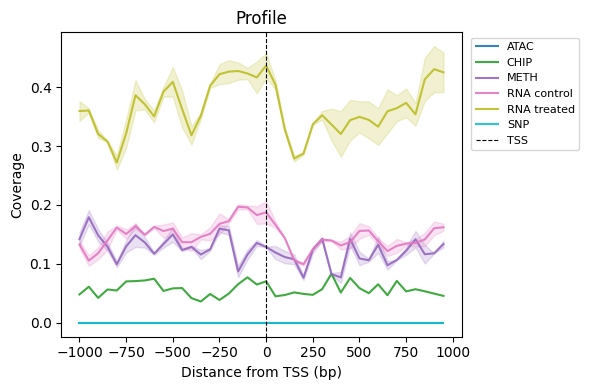

In [ ]:
metadata["assay"] = metadata.index.to_series().apply(lambda s: s.split("-")[0])
metadata["condition"] = [
    "control" if "control" in s else "treated" if "treated" in s else "" for s in metadata.index
]
metadata["group"] = metadata["assay"].str.upper()
metadata.loc[metadata["assay"] == "rna", "group"] += " " + metadata["condition"]
groups_dict = metadata.groupby("group").groups

# Then plot — reference line at 0 is the TSS
ax = qn.metaplot(
    binned,
    groups=groups_dict,
    flip_minus_strand=True,
    error_stat="sem",
    palette="tab10",
    reference_point=0,
    reference_label="TSS",
    xlabel="Distance from TSS (bp)",
    ylabel="Coverage",
    title="Profile",
    figsize=(6, 4),
    filepath=FIG_DIR / "metaplot.png",
)

### Tornado plot (signal heatmap over TSSs)

Each row is one genomic interval (TSS ± window), colour encodes signal intensity.
Intervals are sorted by mean signal of the first panel so all panels share the same row order.

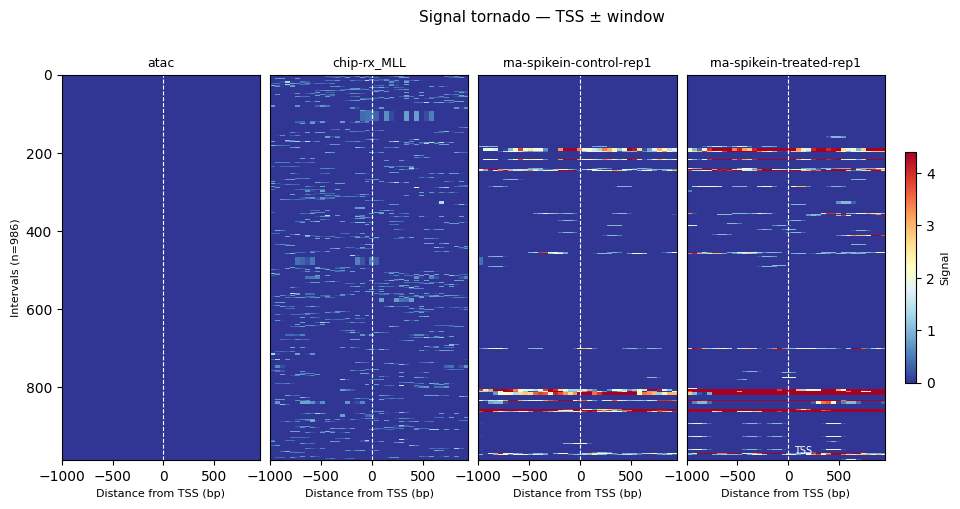

In [ ]:
axes = qn.tornadoplot(
    binned,
    samples=["atac", "chip-rx_MLL", "rna-spikein-control-rep1", "rna-spikein-treated-rep1"],
    flip_minus_strand=True,
    sort_by="mean",
    cmap="RdYlBu_r",
    reference_point=0,
    reference_label="TSS",
    xlabel="Distance from TSS (bp)",
    title="Signal tornado — TSS ± window",
    filepath=FIG_DIR / "tornado_tss.png",
)
plt.show()

---
## Extract Signal for a Single Genomic Region

Use `extract_region` to pull the raw per-base coverage for any genomic locus across all samples.

In [ ]:
runx1_coords = "chr21:34787801-34889760"
region = qn.extract_region(runx1_coords)  # RUNX1 locus (chr21, hg38)
print(f"Region shape: {region.shape}  (samples × positions)")

In [ ]:
region_data = region.compute()  # (samples, positions)
positions = np.arange(region_data.shape[1])

fig, axes = plt.subplots(len(qn.samples), 1, figsize=(12, 1.5 * len(qn.samples)), sharex=True)

if len(qn.samples) == 1:
    axes = [axes]

for ax, sample in zip(axes, region_data.coords["sample"].values):
    ax.fill_between(positions, region_data.sel(sample=sample).values, alpha=0.8)
    ax.set_ylabel(sample, fontsize=7, rotation=0, ha="right", va="center")
    ax.set_yticks([])

axes[-1].set_xlabel("Position (bp)")
fig.suptitle(f"Coverage — {runx1_coords} (RUNX1 locus)")
fig.tight_layout()
fig.savefig(FIG_DIR / "region_RUNX1.png")
plt.show()

---
## Methylation (CpG-level from MethylDackel)

`ms.methylation` is a `MethylStore` — a sparse Zarr store where each chromosome has:
- `positions` — the union of CpG start coordinates (0-based) across all samples
- `methylation_pct` — methylation percentage per site per sample (`NaN` = not covered)
- `n_methylated` / `n_unmethylated` — read counts

In [ ]:
meth = ms.methylation
print(f"Samples : {meth.sample_names}")
for chrom in meth.chromosomes:
    print(f"  {chrom}: {len(meth.get_positions(chrom)):,} CpG sites")

# Lazy DataArray — sample × CpG position
meth_xr = meth.to_xarray(variable="methylation_pct")
print()
print(meth_xr["chr21"])

### Methylation distribution

In [ ]:
meth_data = meth_xr["chr21"].compute()

fig, ax = plt.subplots(figsize=(8, 4))
for sample in meth.sample_names:
    vals = meth_data.sel(sample=sample).values
    vals = vals[~np.isnan(vals)]
    ax.hist(vals, bins=50, alpha=0.6, label=sample, density=True)

ax.set_xlabel("Methylation (%)")
ax.set_ylabel("Density")
ax.set_title("CpG methylation distribution — chr21")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "methylation_distribution.png")
plt.show()

### Replicate correlation at shared CpG sites

In [ ]:
s1_name, s2_name = meth.sample_names[0], meth.sample_names[1]
s1 = meth_data.sel(sample=s1_name).values
s2 = meth_data.sel(sample=s2_name).values

covered = ~np.isnan(s1) & ~np.isnan(s2)
r = np.corrcoef(s1[covered], s2[covered])[0, 1]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hexbin(s1[covered], s2[covered], gridsize=60, cmap="viridis", mincnt=1)
ax.plot([0, 100], [0, 100], "r--", linewidth=0.8)
ax.set_xlabel(f"Methylation % — {s1_name}")
ax.set_ylabel(f"Methylation % — {s2_name}")
ax.set_title(f"CpG replicate correlation\n(n={covered.sum():,} sites, r={r:.3f})")
fig.tight_layout()
fig.savefig(FIG_DIR / "methylation_replicate_correlation.png")
plt.show()

### Extract methylation over a specific region

In [ ]:
region_meth = meth.extract_region(runx1_coords, variable="methylation_pct")
print(f"Shape: {region_meth.shape}  (samples × CpG sites in RUNX1)")
print(f"CpG positions covered: {(~np.isnan(region_meth.values)).sum(axis=1)}")

### Methylation metaplot over promoters

For each 1024 bp promoter window on chr21, CpG sites are assigned to one of 32 bins
relative to the TSS (position 0). Minus-strand promoters are strand-corrected so that
the TSS is always at the centre. The profile shows mean methylation % per bin across all
promoters.

In [ ]:
N_BINS = 32  # bins across the 1024 bp promoter window

# Load promoter windows restricted to chr21
bed = pr.read_bed(BED_FILE)

bed = bed[bed["Chromosome"] == "chr21"].reset_index(drop=True)
win_len = int(bed["End"].iloc[0] - bed["Start"].iloc[0])  # 1024

# Sparse CpG positions and methylation matrix
cpg_pos = meth.get_positions("chr21")  # shape (n_cpg,)
meth_mat = meth_xr["chr21"].compute().values  # shape (n_samples, n_cpg)
n_samp = len(meth.sample_names)

bin_sum = np.zeros((n_samp, N_BINS))
bin_cnt = np.zeros((n_samp, N_BINS))

for _, row in bed.iterrows():
    start, end, strand = int(row["Start"]), int(row["End"]), row["Strand"]
    idx = np.where((cpg_pos >= start) & (cpg_pos < end))[0]
    if idx.size == 0:
        continue
    rel = cpg_pos[idx] - start  # 0-based within window
    if strand == "-":
        rel = (win_len - 1) - rel  # flip: TSS → position 0
    bins = (rel * N_BINS // win_len).clip(0, N_BINS - 1)
    for s in range(n_samp):
        vals = meth_mat[s, idx]
        for b, v in zip(bins, vals):
            if not np.isnan(v):
                bin_sum[s, b] += v
                bin_cnt[s, b] += 1

with np.errstate(invalid="ignore"):
    profile = np.where(bin_cnt > 0, bin_sum / bin_cnt, np.nan)

# x-axis: bp relative to TSS (window centred at 0)
half = win_len / 2
bin_centers = np.linspace(-half, half, N_BINS, endpoint=False) + win_len / (2 * N_BINS)

fig, ax = plt.subplots(figsize=(8, 4))
for i, sample in enumerate(meth.sample_names):
    sns.lineplot(x=bin_centers, y=profile[i], label=sample, ax=ax)

ax.axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.6, label="TSS")
ax.set_xlabel("Distance from TSS (bp)")
ax.set_ylabel("Mean CpG methylation (%)")
ax.set_title(f"Methylation metaplot over promoters — chr21  (n={len(bed)})")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "methylation_metaplot_promoters.png")
plt.show()

In [ ]:
# plot methylation levels at runx1_coords
region_meth_data = region_meth.compute()  # (samples, positions)
positions = np.arange(region_meth_data.shape[1])

# facet by replicate
g = sns.FacetGrid(
    pd.DataFrame(region_meth_data.values, columns=positions, index=meth.sample_names)
    .reset_index()
    .melt(id_vars="index", var_name="position", value_name="methylation"),
    row="index",
    height=3,
    sharex=True,
    sharey=True,
    aspect=6,
)
g.map(sns.scatterplot, "position", "methylation", alpha=0.6, edgecolor=None)
g.set_axis_labels("Position (bp)", "Methylation (%)")
g.set_titles(row_template="{row_name}")
g.figure.suptitle("Methylation profile across RUNX1 locus — chr21", y=1.02)
g.savefig(FIG_DIR / "methylation_profile_RUNX1.png", bbox_inches="tight")
plt.show()

---
## Variant Calls (SNP/indel from VCF)

`ms.variants` is a `VariantStore` — a sparse Zarr store where each chromosome has:
- `positions` — 1-based variant positions (union across all samples)
- `genotype` — integer encoded: `-1` missing, `0` hom-ref, `1` het, `2` hom-alt
- `allele_depth_ref` / `allele_depth_alt` — read depths per allele
- `qual` — per-sample variant quality score

In [ ]:
var = ms.variants
print(f"Samples : {var.sample_names}")
for chrom in var.chromosomes:
    print(f"  {chrom}: {len(var.get_positions(chrom)):,} variant sites")

# Lazy DataArray — sample × variant position
gt_xr = var.to_xarray(variable="genotype")
print()
print(gt_xr["chr21"])

### Genotype summary

In [ ]:
gt_data = gt_xr["chr21"].compute()

labels = {-1: "missing", 0: "hom-ref", 1: "het", 2: "hom-alt"}
print("Genotype counts per sample:")
for sample in var.sample_names:
    gt = gt_data.sel(sample=sample).values
    counts = {labels[k]: int((gt == k).sum()) for k in [-1, 0, 1, 2]}
    print(f"  {sample}: {counts}")

### Variants in a specific region

In [ ]:
REGION = "chr21:5230000-5250000"

region_gt = var.extract_region(REGION, variable="genotype")
region_qual = var.extract_region(REGION, variable="qual")
region_ad_r = var.extract_region(REGION, variable="allele_depth_ref")
region_ad_a = var.extract_region(REGION, variable="allele_depth_alt")

positions = region_gt.coords["position"].values
ref_alleles, alt_alleles = var.get_alleles("chr21")
# subset alleles to positions in this region
all_pos = var.get_positions("chr21")
pos_mask = (all_pos >= int(REGION.split(":")[1].split("-")[0])) & (
    all_pos <= int(REGION.split("-")[1])
)
refs_reg = [ref_alleles[i] for i in np.where(pos_mask)[0]]
alts_reg = [alt_alleles[i] for i in np.where(pos_mask)[0]]

# Build a tidy DataFrame for the first sample
sample = var.sample_names[0]
df_region = pd.DataFrame(
    {
        "pos": positions,
        "ref": refs_reg,
        "alt": alts_reg,
        "genotype": [labels[g] for g in region_gt.sel(sample=sample).values],
        "qual": region_qual.sel(sample=sample).values.round(1),
        "AD_ref": region_ad_r.sel(sample=sample).values,
        "AD_alt": region_ad_a.sel(sample=sample).values,
    }
)
print(f"Variants in {REGION} for sample '{sample}':")
df_region

In [ ]:
# plot allele frequency (AD_alt / depth) across the region
GT_STYLE = {1: ("#1f77b4", "het"), 2: ("#d62728", "hom-alt")}

pos_c = region_gt.coords["position"].values
gt_c = region_gt.sel(sample=sample).values
af_c = region_ad_a.sel(sample=sample).values / (
    region_ad_r.sel(sample=sample).values + region_ad_a.sel(sample=sample).values
)
fig, ax = plt.subplots(figsize=(8, 4))

for g, (color, label) in GT_STYLE.items():
    m = gt_c == g
    ax.vlines(pos_c[m], 0, af_c[m], color=color, linewidth=0.9, alpha=0.7)
    ax.scatter(pos_c[m], af_c[m], color=color, s=25, zorder=3, label=f"{label} (n={m.sum()})")

ax.set_xlabel("Position (bp)")
ax.set_ylabel("Allele frequency  (AD_alt / depth)")
ax.set_title(f"Variant allele frequency — {REGION}  |  sample: {sample}")
ax.set_ylim(0, 1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1))
fig.tight_layout()
fig.savefig(FIG_DIR / "variant_allele_frequency_region.png")
plt.show()

### Variant allele frequency across chr21

Each variant site is drawn as a lollipop at its 1-based genomic coordinate.
Height = allele frequency (`AD_alt / (AD_ref + AD_alt)`).
Colour indicates genotype: **blue** = heterozygous, **red** = homozygous-alt.

In [ ]:
# Compute allele frequency for all chr21 variants
gt_all = var.to_xarray(variable="genotype")["chr21"].compute()
adr_all = var.to_xarray(variable="allele_depth_ref")["chr21"].compute()
ada_all = var.to_xarray(variable="allele_depth_alt")["chr21"].compute()

sample = var.sample_names[0]
pos_all = gt_all.coords["position"].values
gt_vals = gt_all.sel(sample=sample).values
adr_vals = adr_all.sel(sample=sample).values.astype(float)
ada_vals = ada_all.sel(sample=sample).values.astype(float)

total_depth = adr_vals + ada_vals
with np.errstate(invalid="ignore", divide="ignore"):
    af = np.where(total_depth > 0, ada_vals / total_depth, np.nan)

# Keep only called variants (het or hom-alt)
called = gt_vals >= 1
pos_c = pos_all[called]
af_c = af[called]
gt_c = gt_vals[called]

GT_STYLE = {1: ("#1f77b4", "het"), 2: ("#d62728", "hom-alt")}

fig, ax = plt.subplots(figsize=(12, 3))
for g, (color, label) in GT_STYLE.items():
    m = gt_c == g
    ax.vlines(pos_c[m], 0, af_c[m], color=color, linewidth=0.9, alpha=0.7)
    ax.scatter(pos_c[m], af_c[m], color=color, s=25, zorder=3, label=f"{label} (n={m.sum()})")

ax.set_xlabel("Genomic position (chr21, 1-based)")
ax.set_ylabel("Allele frequency  (AD_alt / depth)")
ax.set_title(f"Variant allele frequency — chr21  |  sample: {sample}")
ax.set_ylim(0, 1.08)
ax.legend(framealpha=0.8, loc="upper right", bbox_to_anchor=(1.2, 1))
fig.tight_layout()
fig.savefig(FIG_DIR / "variant_allele_frequency_chr21.png")
plt.show()

---
## Multi-Modal Locus Browser

View all three modalities together for a single genomic region — the same layout as a genome
browser, built directly from the `MultiomicsStore` in a few lines.

Panels (top → bottom, all sharing the same x-axis):
- **Coverage** tracks for selected assay types (ATAC, ChIP, methylation, SNP)
- **Methylation %** at individual CpG sites (one dot per site, per replicate)
- **Variant allele frequency** coloured by genotype (blue = het, red = hom-alt)

In [ ]:
LOCUS = "chr21:5200000-5260000"  # 60 kb window containing called variants
chrom, coords = LOCUS.split(":")
locus_start, locus_end = map(int, coords.split("-"))

# Subset of samples for the coverage tracks (keeps the browser readable)
browser_samples = ["atac", "chip-rx_MLL", "meth-rep1", "snp"]

# --- Coverage ---
cov_locus = qn.extract_region(LOCUS).sel(sample=browser_samples).compute()

# --- Methylation ---
meth_locus = meth.extract_region(LOCUS, variable="methylation_pct").compute()

# --- Variants ---
gt_locus = var.extract_region(LOCUS, variable="genotype").compute()
adr_locus = var.extract_region(LOCUS, variable="allele_depth_ref").compute()
ada_locus = var.extract_region(LOCUS, variable="allele_depth_alt").compute()

print(f"Coverage    : {cov_locus.shape}  (samples × bp)")
print(f"Methylation : {meth_locus.shape}  (samples × CpG sites)")
print(f"Variants    : {gt_locus.shape}  (samples × variant sites)")

In [ ]:
n_cov = len(browser_samples)
n_panels = n_cov + 2  # coverage panels + methylation + variants

fig, axes = plt.subplots(
    n_panels,
    1,
    figsize=(13, 2.2 * n_panels),
    sharex=True,
    gridspec_kw={"height_ratios": [1] * n_cov + [1.5, 1.5], "hspace": 0.08},
)

bp_axis = np.arange(locus_start, locus_end)
cov_colors = ["#2196F3", "#FF5722", "#9C27B0", "#4CAF50"]

# — Coverage panels —
for i, (sample, color) in enumerate(zip(browser_samples, cov_colors)):
    vals = cov_locus.sel(sample=sample).values
    axes[i].fill_between(bp_axis, vals, color=color, alpha=0.75)
    axes[i].set_ylabel(sample, fontsize=8, rotation=0, ha="right", va="center", labelpad=4)
    axes[i].set_yticks([])
    axes[i].spines[["top", "right", "left"]].set_visible(False)

# — Methylation panel —
meth_ax = axes[n_cov]
cpg_colors_br = ["#E91E63", "#FF9800"]
for j, sname in enumerate(meth.sample_names):
    cpg_vals = meth_locus.sel(sample=sname).values
    cpg_positions = meth_locus.coords["position"].values
    valid = ~np.isnan(cpg_vals)
    meth_ax.scatter(
        cpg_positions[valid],
        cpg_vals[valid],
        s=14,
        alpha=0.8,
        color=cpg_colors_br[j],
        label=sname,
        linewidths=0,
    )
meth_ax.set_ylabel("Methylation\n(%)", fontsize=8)
meth_ax.set_ylim(-5, 115)
meth_ax.legend(fontsize=7, loc="upper right")
meth_ax.spines[["top", "right"]].set_visible(False)

# — Variant panel —
var_ax = axes[n_cov + 1]
vsample = var.sample_names[0]
vpos = gt_locus.coords["position"].values
gt_v = gt_locus.sel(sample=vsample).values
adr_v = adr_locus.sel(sample=vsample).values.astype(float)
ada_v = ada_locus.sel(sample=vsample).values.astype(float)
depth = adr_v + ada_v
af_v = np.where(depth > 0, ada_v / depth, np.nan)

GT_STYLE_BR = {1: ("#1565C0", "het"), 2: ("#B71C1C", "hom-alt")}
for g, (color, label) in GT_STYLE_BR.items():
    m = gt_v == g
    if m.any():
        var_ax.vlines(vpos[m], 0, af_v[m], color=color, linewidth=1.5, alpha=0.8)
        var_ax.scatter(
            vpos[m], af_v[m], color=color, s=30, zorder=3, label=f"{label} (n={m.sum()})"
        )

var_ax.set_ylim(0, 1.25)
var_ax.set_ylabel("Allele\nfreq.", fontsize=8)
var_ax.legend(fontsize=7, loc="upper right")
var_ax.set_xlabel(f"Genomic position ({chrom}, bp)")
var_ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"Multi-modal locus view — {LOCUS}", fontsize=13, y=1.01)
fig.savefig(FIG_DIR / "multimodal_locus_browser.png", bbox_inches="tight")
plt.show()

---
## Coverage–Methylation Anti-correlation at Promoters

For `meth-rep1` and `meth-rep2` — the only samples with **both** coverage and methylation data
— we can ask: is chromatin accessibility anti-correlated with DNA methylation?

Classic epigenomics: open chromatin (high read coverage) = low CpG methylation.
Each hexbin represents a 1024 bp promoter window; colour encodes density.

In [ ]:
# Per-promoter mean methylation
cpg_pos_all = meth.get_positions("chr21")
meth_mat_all = meth_xr["chr21"].compute().values  # (n_samples, n_cpg)

bed_chr21 = pr.read_bed(BED_FILE)
bed_chr21 = bed_chr21[bed_chr21["Chromosome"] == "chr21"].reset_index(drop=True)

promo_meth = np.full((len(bed_chr21), len(meth.sample_names)), np.nan)
for i, (_, row) in enumerate(bed_chr21.iterrows()):
    start, end = int(row["Start"]), int(row["End"])
    idx = np.where((cpg_pos_all >= start) & (cpg_pos_all < end))[0]
    if idx.size == 0:
        continue
    for j in range(len(meth.sample_names)):
        vals = meth_mat_all[j, idx]
        valid = vals[~np.isnan(vals)]
        if valid.size > 0:
            promo_meth[i, j] = valid.mean()

n_with_meth = (~np.isnan(promo_meth)).any(axis=1).sum()
print(f"Promoters with ≥1 CpG site covered: {n_with_meth} / {len(bed_chr21)}")

In [ ]:
cov_mean = promoter_signal["mean"].compute()  # (ranges, sample) — already computed in Section 4

fig, axes = plt.subplots(1, len(meth.sample_names), figsize=(10, 4.5), sharey=True)

for j, sname in enumerate(meth.sample_names):
    ax = axes[j]
    cov_vals = cov_mean.sel(sample=sname).values
    meth_vals = promo_meth[:, j]
    valid = ~np.isnan(meth_vals) & (cov_vals > 0)  # exclude zero-coverage promoters

    hb = ax.hexbin(
        np.log1p(cov_vals[valid]),
        meth_vals[valid],
        gridsize=40,
        cmap="viridis",
        mincnt=1,
    )
    r = np.corrcoef(np.log1p(cov_vals[valid]), meth_vals[valid])[0, 1]
    ax.set_xlabel("log1p(mean coverage per bp)", fontsize=9)
    ax.set_title(f"{sname}\nr = {r:.3f}  |  n = {valid.sum():,} promoters", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Mean CpG methylation (%)")
cb = fig.colorbar(hb, ax=axes.ravel().tolist(), shrink=0.6, label="Number of promoters")
fig.suptitle(
    "Chromatin accessibility vs CpG methylation at promoters\n(open chromatin ↔ low methylation)",
    fontsize=11,
    y=1.04,
)
fig.tight_layout()
fig.savefig(FIG_DIR / "coverage_methylation_anticorrelation.png", bbox_inches="tight")
plt.show()

---
## Modality Completeness Dashboard

A quick at-a-glance view of **what data we have per sample** across all three modalities.
Useful for reporting and QC: bars reflect relative magnitude within each metric; grey = not available.

| Metric | Source |
|---|---|
| % bases covered | Coverage store (1 − sparsity) |
| CpG sites covered | Methylation store |
| Variant calls | Variants store |

In [ ]:
meta = ms.get_metadata()
sample_stats = meta[["modalities", "sparsity"]].copy()
sample_stats["pct_bases_covered"] = (100 - meta["sparsity"]).round(3)

# CpG sites covered per methylation sample
meth_cpg = {}
if ms.methylation is not None:
    for sname in meth.sample_names:
        vals = meth_xr["chr21"].sel(sample=sname).compute().values
        meth_cpg[sname] = int((~np.isnan(vals)).sum())
sample_stats["cpg_sites_covered"] = sample_stats.index.map(lambda s: meth_cpg.get(s, np.nan))

# Variant calls per variant sample
var_n = {}
if ms.variants is not None:
    gt_full = var.to_xarray(variable="genotype")["chr21"].compute()
    for sname in var.sample_names:
        var_n[sname] = int((gt_full.sel(sample=sname).values >= 1).sum())
sample_stats["variant_calls"] = sample_stats.index.map(lambda s: var_n.get(s, np.nan))

sample_stats.drop(columns=["sparsity"], inplace=True)
sample_stats

In [ ]:
metrics = ["pct_bases_covered", "cpg_sites_covered", "variant_calls"]
col_labels = ["% bases\ncovered", "CpG sites\ncovered", "Variant\ncalls"]
cmaps_list = ["Blues", "Purples", "Oranges"]

arr = sample_stats[metrics].values.astype(float)
arr_norm = arr.copy()
for col in range(arr.shape[1]):
    col_max = np.nanmax(arr[:, col])
    if col_max > 0:
        arr_norm[:, col] = arr[:, col] / col_max

fig, axes = plt.subplots(1, 3, figsize=(11, 5), sharey=True)

for ax, col_idx, col_label, cmap_name in zip(axes, range(3), col_labels, cmaps_list):
    vals_norm = arr_norm[:, col_idx]
    vals_raw = arr[:, col_idx]
    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(max(v, 0.1)) if not np.isnan(v) else (0.87, 0.87, 0.87, 1.0) for v in vals_norm]

    bars = ax.barh(sample_stats.index, vals_norm, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_xlim(0, 1.4)
    ax.set_xlabel(col_label, fontsize=9)
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.spines[["top", "right", "bottom"]].set_visible(False)

    for i, (bar, raw) in enumerate(zip(bars, vals_raw)):
        if np.isnan(raw):
            ax.text(0.03, i, "n/a", va="center", fontsize=7.5, color="grey")
        elif col_idx == 0:
            ax.text(bar.get_width() + 0.03, i, f"{raw:.2f}%", va="center", fontsize=7.5)
        elif col_idx == 1:
            ax.text(bar.get_width() + 0.03, i, f"{int(raw):,}", va="center", fontsize=7.5)
        else:
            ax.text(bar.get_width() + 0.03, i, f"{int(raw)}", va="center", fontsize=7.5)

    if col_idx > 0:
        ax.tick_params(left=False)

axes[0].set_yticks(range(len(sample_stats)))
axes[0].set_yticklabels(sample_stats.index, fontsize=8.5)
fig.suptitle("Modality completeness dashboard", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "modality_completeness_dashboard.png", bbox_inches="tight")
plt.show()

---
## PCA

Principal component analysis on the promoter signal matrix is a standard QC step: it reveals
whether samples cluster by expected biological groupings (e.g. cell type, treatment) and flags
outliers.

In [ ]:
pca_obj, pca_result = qn.pca(
    promoter_signal["mean"],
    n_components=8,
    nan_handling_strategy="drop",  # remove regions with missing values
)

explained = np.asarray(pca_obj.explained_variance_ratio_)
print("Explained variance per PC:")
for i, ev in enumerate(explained, 1):
    print(f"  PC{i}: {ev:.1%}")

# Scree plot
scree = plot_pca_scree(pca_obj, filepath=FIG_DIR / "pca_scree.png")
plt.show()

# PC1 vs PC2 scatter — colour by a metadata column of your choice
metadata["assay"] = metadata.index.str.split("-").str[0]

scatter = plot_pca_scatter(
    pca_obj,
    pca_result,
    xaxis_pc=1,
    yaxis_pc=2,
    metadata_df=metadata,
    colour_by="assay",
    shape_by="assay",
    height=5,
    filepath=FIG_DIR / "pca_scatter_pc1_pc2.png",
)
plt.show()